#### Case 1: Isobaric evaporation of liquid hydrogen in a 18.09 $m^3$ Cylindrical tank experiment MHTB.

This notebook sets up the isobaric evaporation of liquid hydrogen ($LH_2$) 

In [ ]:
# Ensure that python finds the submodules
import sys
sys.path.append("..") # Adds higher directory to python modules path.

# Scientific computing
import numpy as np

# Visualisation
import matplotlib.pyplot as plt

## Module imports
# Import the storage tank Class
from cryoevap.storage_tanks import Tank

# Import Cryogen class
from cryoevap.cryogens import Cryogen

# Read data from excel
import os
import pandas as pd


In [2]:
# DATOS DEL ESTUDIO PARAMÉTRICO DE WANG Y MÉRIDA

# Operación
P = 101_300.0                 # Pa
T_air = 293.15                # K, supuesto adoptado

# Geometría del tanque cilíndrico, Tabla 3
V_tank = 4.89                 # m^3
d_i = 1.676                   # m
d_o = d_i                     # m
L_tank = 2.217                # m

# Caso de la Figura 12
LF_initial = 0.30
q_target = 0.50               # W/m^2
eta_w_initial = 0.97          # Valor profe

# Horizonte temporal
t_end_hours = 200.0
t_end_seconds = t_end_hours * 3600.0

In [ ]:
# TEMPERATURA DE SATURACIÓN Y U EQUIVALENTE

hydrogen_reference = Cryogen(name="hydrogen")
hydrogen_reference.set_coolprops(P)

T_sat = hydrogen_reference.T_sat
delta_T_initial = T_air - T_sat

U_equivalent = q_target / delta_T_initial

# Comprobación geométrica con tapas planas
radius = d_i / 2.0

V_geometry = np.pi * radius**2 * L_tank

A_lateral = np.pi * d_i * L_tank
A_ends = 2.0 * np.pi * radius**2
A_total_geometry = A_lateral + A_ends

print("CASO BASE DE LA FIGURA 12")
print("=" * 55)
print(f"Presión                        = {P/1000:.4f} kPa")
print(f"Temperatura de saturación      = {T_sat:.8f} K")
print(f"Diferencia inicial de T        = {delta_T_initial:.8f} K")
print(f"Flux objetivo                  = {q_target:.8f} W/m²")
print(f"U equivalente                  = {U_equivalent:.10f} W/(m²·K)")
print(f"Nivel líquido inicial          = {100*LF_initial:.2f} %")
print(f"eta_w provisional              = {eta_w_initial:.4f}")
print()
print("COMPROBACIÓN GEOMÉTRICA")
print("=" * 55)
print(f"Volumen nominal                = {V_tank:.8f} m³")
print(f"Volumen calculado              = {V_geometry:.8f} m³")
print(f"Área lateral                   = {A_lateral:.8f} m²")
print(f"Área de las tapas              = {A_ends:.8f} m²")
print(f"Área total calculada           = {A_total_geometry:.8f} m²")
print(f"Tiempo final                   = {t_end_seconds:.0f} s")

CASO BASE DE LA FIGURA 12
Presión                        = 101.3000 kPa
Temperatura de saturación      = 20.36806760 K
Diferencia inicial de T        = 272.78193240 K
Flux objetivo                  = 0.50000000 W/m²
U equivalente                  = 0.0018329660 W/(m²·K)
Nivel líquido inicial          = 30.00 %
eta_w provisional              = 0.9700

COMPROBACIÓN GEOMÉTRICA
Volumen nominal                = 4.89000000 m³
Volumen calculado              = 4.89106690 m³
Área lateral                   = 11.67319069 m²
Área de las tapas              = 4.41232918 m²
Área total calculada           = 16.08551987 m²
Tiempo final                   = 720000 s


In [5]:
# CONSTRUCCIÓN DEL TANQUE VERTICAL: FIGURA 12

# Objeto de hidrógeno independiente
hydrogen_vertical = Cryogen(name="hydrogen")
hydrogen_vertical.set_coolprops(P)

# Tanque cilíndrico vertical
vertical_tank = Tank(d_i=d_i,d_o=d_o,V=V_tank,vapour_geometry="cylindrical",liquid_geometry="cylindrical",LF=LF_initial)

vertical_tank.cryogen = hydrogen_vertical

# Propiedades térmicas
vertical_tank.set_HeatTransProps(U_L=U_equivalent,U_V=U_equivalent,T_air=T_air,Q_b_fixed=None,Q_roof=0.0,eta_w=eta_w_initial)


In [ ]:
# ESTADO INICIAL DEL TANQUE VERTICAL


V_L_initial_vertical = V_tank * LF_initial
V_V_initial_vertical = V_tank - V_L_initial_vertical

m_L_initial_vertical = vertical_tank.cryogen.rho_L* V_L_initial_vertical

m_V_initial_vertical = vertical_tank.cryogen.rho_V_sat* V_V_initial_vertical

A_wet_vertical = vertical_tank.A_L+ vertical_tank.A_T

A_total_vertical = vertical_tank.A_L+ vertical_tank.A_T+ vertical_tank.A_V

Q_wet_vertical = vertical_tank.Q_L_in+ vertical_tank.Q_b

q_wet_vertical = Q_wet_vertical/ A_wet_vertical

q_wi_vertical = vertical_tank.Q_wi/ vertical_tank.A_V

q_wall_vapour_vertical = vertical_tank.Q_wi/ (vertical_tank.eta_w* vertical_tank.A_V)

ESTADO INICIAL: TANQUE VERTICAL
Geometría
-----------------------------------------------------------------
Altura total, l                  = 2.21651640 m
Altura inicial del vapor, l_V    = 1.55156148 m
Área interfacial/fondo, A_T      = 2.20616459 m²
Área lateral mojada, A_L         = 3.50119332 m²
Área en contacto con vapor, A_V  = 10.37561567 m²
Área total calculada             = 16.08297357 m²

Inventario inicial
-----------------------------------------------------------------
Volumen líquido inicial          = 1.46700000 m³
Volumen de vapor inicial         = 3.42300000 m³
Densidad líquida                 = 70.84929948 kg/m³
Densidad de vapor saturado       = 1.33187372 kg/m³
Masa líquida inicial             = 103.93592234 kg
Masa de vapor inicial            = 4.55900374 kg

Temperaturas iniciales
-----------------------------------------------------------------
T líquido/interfase              = 20.36806760 K
T vapor promedio                 = 20.36806760 K

Calores y fluxes ini

### Horizontal

In [9]:
# CONSTRUCCIÓN DEL TANQUE HORIZONTAL: FIGURA 12

hydrogen_horizontal = Cryogen(name="hydrogen")
hydrogen_horizontal.set_coolprops(P)

horizontal_tank = Tank(d_i=d_i,d_o=d_o,V=V_tank,vapour_geometry="horizontal",liquid_geometry="horizontal",LF=LF_initial,L=L_tank)

horizontal_tank.cryogen = hydrogen_horizontal

horizontal_tank.set_HeatTransProps(U_L=U_equivalent,U_V=U_equivalent,T_air=T_air,Q_b_fixed=0.0,Q_roof=0.0,eta_w=eta_w_initial)

In [ ]:
# ESTADO INICIAL DEL TANQUE HORIZONTAL

V_L_initial_horizontal = V_tank * LF_initial
V_V_initial_horizontal = V_tank - V_L_initial_horizontal

m_L_initial_horizontal = horizontal_tank.cryogen.rho_L* V_L_initial_horizontal

m_V_initial_horizontal = horizontal_tank.cryogen.rho_V_sat* V_V_initial_horizontal

A_total_horizontal = horizontal_tank.A_L+ horizontal_tank.A_V

Q_wet_horizontal = horizontal_tank.Q_L_in+ horizontal_tank.Q_b

q_wet_horizontal = Q_wet_horizontal/ horizontal_tank.A_L

q_wi_horizontal = horizontal_tank.Q_wi/ horizontal_tank.A_V

q_wall_vapour_horizontal = horizontal_tank.Q_wi/ (horizontal_tank.eta_w* horizontal_tank.A_V)

print("Calores y fluxes iniciales")
print("-" * 65)
print(f"Q_L_in                            = {horizontal_tank.Q_L_in:.10f} W")
print(f"Q_b                               = {horizontal_tank.Q_b:.10f} W")
print(f"Q_wi                              = {horizontal_tank.Q_wi:.10f} W")
print(f"(Q_L_in + Q_b)/A_L               = {q_wet_horizontal:.10f} W/m²")
print(f"Q_wi/A_V                          = {q_wi_horizontal:.10f} W/m²")
print(f"Q_wi/(eta_w A_V)                  = {q_wall_vapour_horizontal:.10f} W/m²")

ESTADO INICIAL: TANQUE HORIZONTAL
Geometría
-----------------------------------------------------------------
Diámetro/altura total, l          = 1.67600000 m
Altura inicial de líquido, z      = 0.44444676 m
Altura inicial del vapor, l_V     = 1.23155324 m
Área interfacial, A_T             = 3.28044043 m²
Área de pared mojada, A_L         = 6.36023197 m²
Área en contacto con vapor, A_V   = 9.72528790 m²
Área total calculada              = 16.08551987 m²

Inventario inicial
-----------------------------------------------------------------
Volumen líquido inicial           = 1.46700000 m³
Volumen de vapor inicial          = 3.42300000 m³
Densidad líquida                  = 70.84929948 kg/m³
Densidad de vapor saturado        = 1.33187372 kg/m³
Masa líquida inicial              = 103.93592234 kg
Masa de vapor inicial             = 4.55900374 kg

Temperaturas iniciales
-----------------------------------------------------------------
T líquido/interfase               = 20.36806760 K
T vapor

In [ ]:
# COMPARACIÓN DEL ESTADO INICIAL

# Calor total que atraviesa inicialmente toda la pared.
# Q_wi contiene solo la fracción eta_w del calor de la pared
# en contacto con vapor, por eso se divide por eta_w.
Q_wall_total_vertical = vertical_tank.Q_L_in+ vertical_tank.Q_b+ vertical_tank.Q_wi / vertical_tank.eta_w

Q_wall_total_horizontal = horizontal_tank.Q_L_in+ horizontal_tank.Q_b+ horizontal_tank.Q_wi / horizontal_tank.eta_w

# Valores esperados a partir de q'' por el área total
Q_wall_expected_vertical = q_target* (vertical_tank.A_L+ vertical_tank.A_T+ vertical_tank.A_V)

Q_wall_expected_horizontal = q_target* (horizontal_tank.A_L+ horizontal_tank.A_V)

z_over_D = horizontal_tank.z / d_i

print("Calor total inicial a través de la pared")
print("-" * 70)
print(f"Vertical, desde términos Q  = {Q_wall_total_vertical:.10f} W")
print(f"Vertical, q'' por área      = {Q_wall_expected_vertical:.10f} W")
print(f"Horizontal, desde términos  = {Q_wall_total_horizontal:.10f} W")
print(f"Horizontal, q'' por área    = {Q_wall_expected_horizontal:.10f} W")

print()
print(f"Diferencia horizontal-vertical = {Q_wall_total_horizontal - Q_wall_total_vertical:.10f} W")

COMPARACIÓN DEL ESTADO INICIAL
Inventario
----------------------------------------------------------------------
Masa líquida vertical       = 103.93592234 kg
Masa líquida horizontal     = 103.93592234 kg
Masa de vapor vertical      = 4.55900374 kg
Masa de vapor horizontal    = 4.55900374 kg

Áreas
----------------------------------------------------------------------
Área total vertical         = 16.08297357 m²
Área total horizontal       = 16.08551987 m²
z/D horizontal              = 0.26518303

Calor total inicial a través de la pared
----------------------------------------------------------------------
Vertical, desde términos Q  = 8.0414867871 W
Vertical, q'' por área      = 8.0414867871 W
Horizontal, desde términos  = 8.0427599365 W
Horizontal, q'' por área    = 8.0427599365 W

Diferencia horizontal-vertical = 0.0012731494 W


Prueba con t = 5h para ver si funciona

In [ ]:
# TANQUE VERTICAL NUEVO PARA SIMULACIÓN CORTA

hydrogen_vertical_short = Cryogen(name="hydrogen")
hydrogen_vertical_short.set_coolprops(P)

vertical_short = Tank(
    d_i=d_i,
    d_o=d_o,
    V=V_tank,
    vapour_geometry="cylindrical",
    liquid_geometry="cylindrical",
    LF=LF_initial
)

vertical_short.cryogen = hydrogen_vertical_short

vertical_short.set_HeatTransProps(
    U_L=U_equivalent,
    U_V=U_equivalent,
    T_air=T_air,
    Q_b_fixed=None,
    Q_roof=0.0,
    eta_w=eta_w_initial
)

Tanque vertical nuevo construido.


In [ ]:
# DISCRETIZACIÓN DE LA SIMULACIÓN CORTA

dz_target = 0.01       # m
output_interval = 60   # s
t_short_hours = 5.0
t_short_seconds = int(t_short_hours * 3600)

# Número de nodos en la región de vapor
n_z_vertical_short = max(3,1 + int(np.round(vertical_short.l_V / dz_target)))

# La clase utiliza una coordenada adimensional entre 0 y 1
vertical_short.z_grid = np.linspace(0.0,1.0,n_z_vertical_short)

# Intervalo entre resultados guardados
vertical_short.time_interval = output_interval

# Espaciamiento físico realmente obtenido
dz_physical_vertical = (vertical_short.l_V/ (n_z_vertical_short - 1))

print("CONFIGURACIÓN DE LA SIMULACIÓN CORTA")
print("=" * 65)
print(f"Tiempo total                     = {t_short_hours:.2f} h")
print(f"Tiempo total                     = {t_short_seconds:d} s")
print(f"Intervalo de resultados          = {output_interval:d} s")
print(f"Altura inicial de vapor          = {vertical_short.l_V:.8f} m")
print(f"Número de nodos de vapor         = {n_z_vertical_short:d}")
print(f"Espaciamiento físico aproximado  = {dz_physical_vertical:.8f} m")
print(f"Tiempo característico tau        = {vertical_short.tau/3600:.8f} h")

CONFIGURACIÓN DE LA SIMULACIÓN CORTA
Tiempo total                     = 5.00 h
Tiempo total                     = 18000 s
Intervalo de resultados          = 60 s
Altura inicial de vapor          = 1.55156148 m
Número de nodos de vapor         = 156
Espaciamiento físico aproximado  = 0.01001007 m
Tiempo característico tau        = 72.05923619 h


In [16]:
# EJECUCIÓN DE LA SIMULACIÓN CORTA VERTICAL

vertical_short.evaporate(t_short_seconds)

print("Simulación terminada.")

Simulación terminada.


In [ ]:
# VARIABLES DE LA SIMULACIÓN CORTA

time_vertical_short_h = (vertical_short.sol.t / 3600.0)
V_L_vertical_short = (vertical_short.data["V_L"])

LF_vertical_short = (vertical_short.data["LF"])

Tv_avg_vertical_short = (vertical_short.data["Tv_avg"])

m_L_vertical_short = vertical_short.cryogen.rho_L* V_L_vertical_short

# Derivada de la masa líquida: negativa durante evaporación
dMLdt_vertical_short = vertical_short.cryogen.rho_L* vertical_short.data["dV_L"]* 3600.0

# Tasa positiva de evaporación
BL_vertical_short = vertical_short.data["B_L"]* 3600.0

# Tasa de BOG
BOG_vertical_short = vertical_short.data["BOG"]* 3600.0

In [20]:
# RESUMEN DE LA SIMULACIÓN CORTA

print("SIMULACIÓN CORTA: TANQUE VERTICAL")
print("=" * 70)

print("Valores iniciales")
print("-" * 70)
print(f"LF inicial                       = {LF_vertical_short[0]:.10f}")
print(f"Masa líquida inicial             = {m_L_vertical_short[0]:.10f} kg")
print(f"T vapor promedio inicial         = {Tv_avg_vertical_short[0]:.10f} K")
print(f"Evaporación inicial, B_L         = {BL_vertical_short[0]:.10f} kg/h")
print(f"BOG inicial                      = {BOG_vertical_short[0]:.10f} kg/h")

print()
print("Valores a las cinco horas")
print("-" * 70)
print(f"LF final                         = {LF_vertical_short[-1]:.10f}")
print(f"Masa líquida final               = {m_L_vertical_short[-1]:.10f} kg")
print(f"T vapor promedio final           = {Tv_avg_vertical_short[-1]:.10f} K")
print(f"dM_L/dt final                    = {dMLdt_vertical_short[-1]:.10f} kg/h")
print(f"Evaporación final, B_L           = {BL_vertical_short[-1]:.10f} kg/h")
print(f"BOG final                        = {BOG_vertical_short[-1]:.10f} kg/h")

print()
print("Rangos durante la simulación")
print("-" * 70)
print(
    f"Tv_avg mínimo y máximo           = "
    f"{np.min(Tv_avg_vertical_short):.10f}, "
    f"{np.max(Tv_avg_vertical_short):.10f} K"
)
print(
    f"dM_L/dt mínimo y máximo          = "
    f"{np.min(dMLdt_vertical_short):.10f}, "
    f"{np.max(dMLdt_vertical_short):.10f} kg/h"
)
print(
    f"B_L mínimo y máximo              = "
    f"{np.min(BL_vertical_short):.10f}, "
    f"{np.max(BL_vertical_short):.10f} kg/h"
)
print(
    f"BOG mínimo y máximo              = "
    f"{np.min(BOG_vertical_short):.10f}, "
    f"{np.max(BOG_vertical_short):.10f} kg/h"
)

SIMULACIÓN CORTA: TANQUE VERTICAL
Valores iniciales
----------------------------------------------------------------------
LF inicial                       = 0.3000000000
Masa líquida inicial             = 103.9359223417 kg
T vapor promedio inicial         = 20.3680782788 K
Evaporación inicial, B_L         = 0.0721173674 kg/h
BOG inicial                      = 0.0721173674 kg/h

Valores a las cinco horas
----------------------------------------------------------------------
LF final                         = 0.2990862402
Masa líquida final               = 103.6193474479 kg
T vapor promedio final           = 20.4091815749 K
dM_L/dt final                    = -0.0633309378 kg/h
Evaporación final, B_L           = 0.0721808575 kg/h
BOG final                        = 0.0730976428 kg/h

Rangos durante la simulación
----------------------------------------------------------------------
Tv_avg mínimo y máximo           = 20.3680782788, 20.4091815749 K
dM_L/dt mínimo y máximo          = -0.0633

In [ ]:
# CORRECCIÓN DE B_L PARA EL TANQUE VERTICAL

latent_heat = (vertical_short.cryogen.h_V- vertical_short.cryogen.h_L)

# Evaporación artificial provocada por contar Q_b dos veces
bottom_double_count_kg_h = (vertical_short.Q_b/ latent_heat* 3600.0)

BL_vertical_corrected = (BL_vertical_short- bottom_double_count_kg_h)

print("CORRECCIÓN DEL DOBLE CONTEO DEL FONDO")
print("=" * 70)

print(f"Calor del fondo, Q_b                  = {vertical_short.Q_b:.10f} W")

print(f"Calor latente                         = {latent_heat:.10f} J/kg")

print(f"Equivalente evaporativo de Q_b        = {bottom_double_count_kg_h:.10f} kg/h")

print(f"B_L almacenado final                  = "f"{BL_vertical_short[-1]:.10f} kg/h")

print(f"B_L corregido final                   = {BL_vertical_corrected[-1]:.10f} kg/h")

print(f"-dM_L/dt final                        = {-dMLdt_from_mass[-1]:.10f} kg/h")

CORRECCIÓN DEL DOBLE CONTEO DEL FONDO
Calor del fondo, Q_b                  = 1.1030822957 W
Calor latente                         = 448715.2803918666 J/kg
Equivalente evaporativo de Q_b        = 0.0088499243 kg/h
B_L almacenado final                  = 0.0721808575 kg/h
B_L corregido final                   = 0.0633309332 kg/h
-dM_L/dt final                        = 0.0633308985 kg/h


In [ ]:
# BOG MEDIANTE BALANCE TOTAL DE MASA

m_V_vertical_short = (vertical_short.data["rho_V_avg"]* (V_tank- V_L_vertical_short))

dMVdt_from_mass = np.gradient(m_V_vertical_short,time_vertical_short_h)

BOG_vertical_mass_balance = -(dMLdt_from_mass+ dMVdt_from_mass)

mass_released_mass_balance = np.trapezoid(BOG_vertical_mass_balance,time_vertical_short_h)

print("BOG MEDIANTE BALANCE TOTAL")
print("=" * 70)

print(f"Masa de vapor inicial                 = {m_V_vertical_short[0]:.10f} kg")

print(f"Masa de vapor final                   = {m_V_vertical_short[-1]:.10f} kg")

print(f"dM_V/dt final                         = {dMVdt_from_mass[-1]:.10f} kg/h")

print(f"BOG almacenado final                  = {BOG_vertical_short[-1]:.10f} kg/h")

print(f"BOG por balance de masa, final         = {BOG_vertical_mass_balance[-1]:.10f} kg/h")

print(f"Masa liberada por balance             = {mass_released_mass_balance:.10f} kg")

BOG MEDIANTE BALANCE TOTAL
Masa de vapor inicial                 = 4.5589996625 kg
Masa de vapor final                   = 4.5530822338 kg
dM_V/dt final                         = -0.0009643147 kg/h
BOG almacenado final                  = 0.0730976428 kg/h
BOG por balance de masa, final         = 0.0642952132 kg/h
Masa liberada por balance             = 0.3224923226 kg


In [ ]:
# TASAS OFICIALES POR BALANCE DE MASA: TANQUE VERTICAL

# Masa líquida
mL_vertical_short = (vertical_short.cryogen.rho_L* vertical_short.data["V_L"])

# Masa de vapor
mV_vertical_short = (vertical_short.data["rho_V_avg"]* (V_tank- vertical_short.data["V_L"]))

# Derivadas respecto del tiempo en horas
dMLdt_vertical_model = np.gradient(mL_vertical_short,time_vertical_short_h)

dMVdt_vertical_model = np.gradient(mV_vertical_short,time_vertical_short_h)

# Tasa positiva de evaporación
evap_vertical_model = -dMLdt_vertical_model

# Tasa de BOG por balance total de masa
BOG_vertical_model = -(dMLdt_vertical_model+ dMVdt_vertical_model)

# Cambio de masa total del tanque
delta_total_mass_vertical = (mL_vertical_short[-1]+ mV_vertical_short[-1]- mL_vertical_short[0]- mV_vertical_short[0])

# Masa liberada integrando el BOG
mass_released_vertical = np.trapezoid(BOG_vertical_model,time_vertical_short_h)



TASAS OFICIALES: TANQUE VERTICAL
Evaporación inicial              = 0.0632689460 kg/h
Evaporación final                = 0.0633308985 kg/h
BOG inicial                      = 0.0648197095 kg/h
BOG final                        = 0.0642952132 kg/h

Cambio total de masa del tanque  = -0.3224923226 kg
Masa liberada por BOG            = 0.3224923226 kg
Error de balance                 = -2.681e-14 kg


Simulacion corta horizontal nueva con 5 h

In [27]:
# TANQUE HORIZONTAL NUEVO PARA SIMULACIÓN CORTA

hydrogen_horizontal_short = Cryogen(name="hydrogen")
hydrogen_horizontal_short.set_coolprops(P)

horizontal_short = Tank(
    d_i=d_i,
    d_o=d_o,
    V=V_tank,
    vapour_geometry="horizontal",
    liquid_geometry="horizontal",
    LF=LF_initial,
    L=L_tank
)

horizontal_short.cryogen = hydrogen_horizontal_short

horizontal_short.set_HeatTransProps(
    U_L=U_equivalent,
    U_V=U_equivalent,
    T_air=T_air,
    Q_b_fixed=0.0,
    Q_roof=0.0,
    eta_w=eta_w_initial
)


In [ ]:
# DISCRETIZACIÓN DE LA SIMULACIÓN CORTA HORIZONTAL

n_z_horizontal_short = max(3,1 + int(np.round(horizontal_short.l_V / dz_target)))

horizontal_short.z_grid = np.linspace(0.0,1.0,n_z_horizontal_short)

horizontal_short.time_interval = output_interval

dz_physical_horizontal = (horizontal_short.l_V/ (n_z_horizontal_short - 1))

print("CONFIGURACIÓN DE LA SIMULACIÓN CORTA HORIZONTAL")
print("=" * 70)
print(f"Tiempo total                     = {t_short_hours:.2f} h")
print(f"Tiempo total                     = {t_short_seconds:d} s")
print(f"Intervalo de resultados          = {output_interval:d} s")
print(f"Altura inicial de vapor          = {horizontal_short.l_V:.8f} m")
print(f"Número de nodos de vapor         = {n_z_horizontal_short:d}")
print(f"Espaciamiento físico aproximado  = {dz_physical_horizontal:.8f} m")
print(f"Tiempo característico tau        = {horizontal_short.tau/3600:.8f} h")

CONFIGURACIÓN DE LA SIMULACIÓN CORTA HORIZONTAL
Tiempo total                     = 5.00 h
Tiempo total                     = 18000 s
Intervalo de resultados          = 60 s
Altura inicial de vapor          = 1.23155324 m
Número de nodos de vapor         = 124
Espaciamiento físico aproximado  = 0.01001263 m
Tiempo característico tau        = 84.93001150 h


In [ ]:
# EJECUCIÓN DE LA SIMULACIÓN CORTA HORIZONTAL (aun se demora harto)

horizontal_short.evaporate(t_short_seconds)

Simulación horizontal terminada.


In [ ]:
# VARIABLES Y TASAS OFICIALES: TANQUE HORIZONTAL

time_horizontal_short_h = (horizontal_short.sol.t / 3600.0)

V_L_horizontal_short = horizontal_short.data["V_L"]
LF_horizontal_short = horizontal_short.data["LF"]
Tv_avg_horizontal_short = horizontal_short.data["Tv_avg"]

mL_horizontal_short = (horizontal_short.cryogen.rho_L* V_L_horizontal_short)

mV_horizontal_short = (horizontal_short.data["rho_V_avg"]* (V_tank- V_L_horizontal_short))

dMLdt_horizontal_model = np.gradient(mL_horizontal_short,time_horizontal_short_h)

dMVdt_horizontal_model = np.gradient(mV_horizontal_short,time_horizontal_short_h)

evap_horizontal_model = -dMLdt_horizontal_model


BOG_horizontal_model = -(dMLdt_horizontal_model+ dMVdt_horizontal_model)

delta_total_mass_horizontal = (mL_horizontal_short[-1]+ mV_horizontal_short[-1]- mL_horizontal_short[0]- mV_horizontal_short[0])

mass_released_horizontal = np.trapezoid(BOG_horizontal_model,time_horizontal_short_h)

In [33]:
# RESUMEN DE LA SIMULACIÓN CORTA HORIZONTAL

print("SIMULACIÓN CORTA: TANQUE HORIZONTAL")
print("=" * 70)

print("Valores iniciales")
print("-" * 70)
print(f"LF inicial                       = {LF_horizontal_short[0]:.10f}")
print(f"Masa líquida inicial             = {mL_horizontal_short[0]:.10f} kg")
print(f"Masa de vapor inicial            = {mV_horizontal_short[0]:.10f} kg")
print(f"T vapor promedio inicial         = {Tv_avg_horizontal_short[0]:.10f} K")
print(f"Evaporación inicial numérica     = {evap_horizontal_model[0]:.10f} kg/h")
print(f"BOG inicial numérico             = {BOG_horizontal_model[0]:.10f} kg/h")

print()
print("Valores a las cinco horas")
print("-" * 70)
print(f"LF final                         = {LF_horizontal_short[-1]:.10f}")
print(f"Masa líquida final               = {mL_horizontal_short[-1]:.10f} kg")
print(f"Masa de vapor final              = {mV_horizontal_short[-1]:.10f} kg")
print(f"T vapor promedio final           = {Tv_avg_horizontal_short[-1]:.10f} K")
print(f"dM_L/dt final                    = {dMLdt_horizontal_model[-1]:.10f} kg/h")
print(f"Evaporación final                = {evap_horizontal_model[-1]:.10f} kg/h")
print(f"BOG final                        = {BOG_horizontal_model[-1]:.10f} kg/h")

print()
print("Balance total")
print("-" * 70)
print(f"Cambio total de masa del tanque  = {delta_total_mass_horizontal:.10f} kg")
print(f"Masa liberada por BOG            = {mass_released_horizontal:.10f} kg")
print(
    f"Error de balance                 = "
    f"{mass_released_horizontal + delta_total_mass_horizontal:.3e} kg"
)

print()
print("Rangos")
print("-" * 70)
print(
    f"Tv_avg mínimo y máximo           = "
    f"{np.min(Tv_avg_horizontal_short):.10f}, "
    f"{np.max(Tv_avg_horizontal_short):.10f} K"
)
print(
    f"Evaporación mínima y máxima      = "
    f"{np.min(evap_horizontal_model):.10f}, "
    f"{np.max(evap_horizontal_model):.10f} kg/h"
)
print(
    f"BOG mínimo y máximo              = "
    f"{np.min(BOG_horizontal_model):.10f}, "
    f"{np.max(BOG_horizontal_model):.10f} kg/h"
)

SIMULACIÓN CORTA: TANQUE HORIZONTAL
Valores iniciales
----------------------------------------------------------------------
LF inicial                       = 0.3000000000
Masa líquida inicial             = 103.9359223417 kg
Masa de vapor inicial            = 4.5590026251 kg
T vapor promedio inicial         = 20.3680675984 K
Evaporación inicial numérica     = 0.0633587122 kg/h
BOG inicial numérico             = 0.0649375736 kg/h

Valores a las cinco horas
----------------------------------------------------------------------
LF final                         = 0.2990845043
Masa líquida final               = 103.6187460368 kg
Masa de vapor final              = 4.5534076718 kg
T vapor promedio final           = 20.4081011923 K
dM_L/dt final                    = -0.0634667537 kg/h
Evaporación final                = 0.0634667537 kg/h
BOG final                        = 0.0643551573 kg/h

Balance total
----------------------------------------------------------------------
Cambio total de mas

In [ ]:
# COMPARACIÓN BASE VERTICAL-HORIZONTAL A LAS CINCO HORAS

delta_Tv_vertical = (Tv_avg_vertical_short[-1]- vertical_short.cryogen.T_sat)

delta_Tv_horizontal = (Tv_avg_horizontal_short[-1]- horizontal_short.cryogen.T_sat)

difference_Tv_H_minus_V = (Tv_avg_horizontal_short[-1]- Tv_avg_vertical_short[-1])

difference_LF_H_minus_V = (LF_horizontal_short[-1]- LF_vertical_short[-1])

difference_mL_H_minus_V = (mL_horizontal_short[-1]- mL_vertical_short[-1])

difference_evap_H_minus_V = (evap_horizontal_model[-1]- evap_vertical_model[-1])

difference_BOG_H_minus_V = (BOG_horizontal_model[-1]- BOG_vertical_model[-1])


print("Tasas")
print("-" * 72)
print(f"Evaporación vertical             = {evap_vertical_model[-1]:.10f} kg/h")

print(f"Evaporación horizontal           = {evap_horizontal_model[-1]:.10f} kg/h")
print(f"Diferencia de evaporación        = {difference_evap_H_minus_V:.10f} kg/h")

print(f"BOG vertical                     = {BOG_vertical_model[-1]:.10f} kg/h")
print(f"BOG horizontal                   = {BOG_horizontal_model[-1]:.10f} kg/h")
print(f"Diferencia de BOG                = {difference_BOG_H_minus_V:.10f} kg/h")

COMPARACIÓN BASAL A LAS CINCO HORAS
Temperatura de vapor
------------------------------------------------------------------------
Tv vertical                      = 20.4091815749 K
Tv horizontal                    = 20.4081011923 K
Tv - Tsat vertical               = 0.0411139765 K
Tv - Tsat horizontal             = 0.0400335939 K
Diferencia horizontal-vertical   = -0.0010803826 K

Inventario líquido
------------------------------------------------------------------------
LF vertical                      = 0.2990862402
LF horizontal                    = 0.2990845043
Diferencia de LF                 = -1.7359092856e-06
Diferencia de masa líquida       = -0.0006014111 kg

Tasas
------------------------------------------------------------------------
Evaporación vertical             = 0.0633308985 kg/h
Evaporación horizontal           = 0.0634667537 kg/h
Diferencia de evaporación        = 0.0001358552 kg/h
BOG vertical                     = 0.0642952132 kg/h
BOG horizontal                 

In [ ]:
# Diferencias relativas respecto del resultado vertical

relative_difference_Tv_rise = (difference_Tv_H_minus_V/ delta_Tv_vertical* 100.0)

relative_difference_evap = (difference_evap_H_minus_V/ evap_vertical_model[-1]* 100.0)

relative_difference_BOG = (difference_BOG_H_minus_V/ BOG_vertical_model[-1]* 100.0)

print()
print("DIFERENCIAS RELATIVAS")
print("=" * 72)

print(f"Diferencia relativa en aumento de Tv = {relative_difference_Tv_rise:.6f} %")

print(f"Diferencia relativa en evaporación   = {relative_difference_evap:.6f} %")

print(f"Diferencia relativa en BOG           = {relative_difference_BOG:.6f} %")


DIFERENCIAS RELATIVAS
Diferencia relativa en aumento de Tv = -2.627775 %
Diferencia relativa en evaporación   = 0.214516 %
Diferencia relativa en BOG           = 0.093233 %


In [ ]:
# SENSIBILIDAD GRUESA DE eta_w

eta_values_coarse = [
    0.30,
    0.50,
    0.70,
    0.85,
    0.97
]

eta_sensitivity_vertical = []

for eta_value in eta_values_coarse:

    print(
        f"Ejecutando eta_w = {eta_value:.2f}..."
    )

    result = simulate_vertical_eta(
        eta_value
    )

    eta_sensitivity_vertical.append(
        result
    )

print("Sensibilidad terminada.")

Ejecutando eta_w = 0.30...
Ejecutando eta_w = 0.50...
Ejecutando eta_w = 0.70...
Ejecutando eta_w = 0.85...
Ejecutando eta_w = 0.97...
Sensibilidad terminada.


In [ ]:
# RESUMEN DE LA SENSIBILIDAD DE eta_w

header = (
    f"{'eta_w':>8}"
    f"{'Tv(5h) [K]':>15}"
    f"{'Tv-Tsat [K]':>15}"
    f"{'LF(5h)':>14}"
    f"{'Evap. [kg/h]':>17}"
    f"{'BOG [kg/h]':>15}"
    f"{'nfev':>10}"
)

print(header)
print("-" * len(header))

for result in eta_sensitivity_vertical:

    print(
        f"{result['eta_w']:>8.2f}"
        f"{result['Tv_final']:>15.8f}"
        f"{result['delta_Tv_final']:>15.8f}"
        f"{result['LF_final']:>14.9f}"
        f"{result['evap_final']:>17.9f}"
        f"{result['BOG_final']:>15.9f}"
        f"{result['nfev']:>10d}"
    )

   eta_w     Tv(5h) [K]    Tv-Tsat [K]        LF(5h)     Evap. [kg/h]     BOG [kg/h]      nfev
----------------------------------------------------------------------------------------------
    0.30    21.41033910     1.04227150   0.299469845      0.037353221    0.086751997      1808
    0.50    21.09407364     0.72600604   0.299356073      0.045004142    0.080135876      1592
    0.70    20.79299460     0.42492700   0.299241662      0.052745826    0.073358862      1700
    0.85    20.57665574     0.20858814   0.299155450      0.058608024    0.068331637      1664
    0.97    20.40918157     0.04111398   0.299086240      0.063330898    0.064295213      1706


## Importación de datos 

In [ ]:
excel_path = os.path.join("..","data","Data_wang_merida.xlsx")

# LECTURA COMPLETA DEL EXCEL

wm_sheets = pd.read_excel(excel_path,sheet_name=None)


In [44]:
# FUNCIÓN PARA EXTRAER CURVAS DESDE UN DATAFRAME

def extract_curve(
    dataframe,
    time_column,
    value_column
):
    """
    Extrae y limpia una curva temporal desde un DataFrame.

    Parameters
    ----------
    dataframe : pandas.DataFrame
        Pestaña del Excel.
    time_column : str
        Nombre de la columna temporal.
    value_column : str
        Nombre de la columna con la variable.

    Returns
    -------
    pandas.DataFrame
        DataFrame con columnas 'time' y 'value'.
    """

    curve = dataframe[
        [
            time_column,
            value_column
        ]
    ].copy()

    curve.columns = [
        "time",
        "value"
    ]

    curve["time"] = pd.to_numeric(
        curve["time"],
        errors="coerce"
    )

    curve["value"] = pd.to_numeric(
        curve["value"],
        errors="coerce"
    )

    curve = curve.dropna(
        subset=[
            "time",
            "value"
        ]
    )

    curve = curve.sort_values(
        by="time"
    )

    curve = curve.reset_index(
        drop=True
    )

    return curve

In [45]:
# FIGURA 12(a): TEMPERATURAS

sheet_T = wm_sheets["12a_T"]

Tl_wm = extract_curve(
    dataframe=sheet_T,
    time_column="t_Tl_h",
    value_column="Tl_K"
)

Tv_vert_wm = extract_curve(
    dataframe=sheet_T,
    time_column="t_Tv_vert_h",
    value_column="Tv_vert_K"
)

Tv_horiz_wm = extract_curve(
    dataframe=sheet_T,
    time_column="t_Tv_horiz_h",
    value_column="Tv_horiz_K"
)

print("Temperatura líquida:")
print(Tl_wm.head())

print()
print("Temperatura de vapor vertical:")
print(Tv_vert_wm.head())

print()
print("Temperatura de vapor horizontal:")
print(Tv_horiz_wm.head())

Temperatura líquida:
        time      value
0   0.167224  20.426794
1   3.846154  20.426851
2   8.528428  20.426924
3  13.210702  20.426997
4  23.913043  20.427164

Temperatura de vapor vertical:
       time      value
0  0.167224  20.666669
1  0.501672  20.813092
2  1.337793  20.943946
3  2.173913  21.049878
4  4.515050  21.109105

Temperatura de vapor horizontal:
       time      value
0  0.167224  20.433024
1  0.167224  20.595018
2  0.836120  20.750792
3  1.839465  20.869188
4  6.521739  20.897298


In [46]:
# FIGURA 12(b): NIVEL LÍQUIDO

sheet_LF = wm_sheets["12b_LF"]

LF_wm = extract_curve(
    dataframe=sheet_LF,
    time_column="t_common_h",
    value_column="LF_common_pct"
)


# FIGURA 12(c): MASA LÍQUIDA

sheet_mL = wm_sheets["12c_mL"]

mL_wm = extract_curve(
    dataframe=sheet_mL,
    time_column="t_common_h",
    value_column="mL_common_kg"
)

print("Curva de nivel líquido:")
print(LF_wm.head())

print()
print("Curva de masa líquida:")
print(mL_wm.head())

Curva de nivel líquido:
           time      value
0  7.105427e-15  30.015480
1  3.980100e+00  29.916532
2  8.955224e+00  29.805231
3  1.426202e+01  29.675364
4  2.172471e+01  29.496029

Curva de masa líquida:
           time       value
0 -7.105427e-15  105.653128
1  4.060018e+00  105.323820
2  1.076787e+01  104.731065
3  1.853486e+01  104.105379
4  2.947926e+01  103.150384


In [47]:
# FIGURA 12(d): CAMBIO DE MASA LÍQUIDA

sheet_dMLdt = wm_sheets["12d_dMLdt"]

dMLdt_vert_wm = extract_curve(
    dataframe=sheet_dMLdt,
    time_column="t_vert_h",
    value_column="dMLdt_vert_kg_h"
)

dMLdt_horiz_wm = extract_curve(
    dataframe=sheet_dMLdt,
    time_column="t_horiz_h",
    value_column="dMLdt_horiz_kg_h"
)

print("dmL/dt vertical:")
print(dMLdt_vert_wm.head())

print()
print("dmL/dt horizontal:")
print(dMLdt_horiz_wm.head())

dmL/dt vertical:
       time     value
0  0.000000 -0.049689
1  0.333333 -0.054658
2  1.000000 -0.060870
3  1.833333 -0.068737
4  3.000000 -0.079710

dmL/dt horizontal:
       time     value
0  0.000000 -0.063354
1  0.833333 -0.067598
2  1.166667 -0.070497
3  1.666667 -0.073706
4  2.166667 -0.078675


In [48]:
# FIGURA 12(e): BOG

sheet_BOG = wm_sheets["12e_BOG"]

BOG_vert_wm = extract_curve(
    dataframe=sheet_BOG,
    time_column="t_vert_h",
    value_column="BOG_vert_kg_h"
)

BOG_horiz_wm = extract_curve(
    dataframe=sheet_BOG,
    time_column="t_horiz_h",
    value_column="BOG_horiz_kg_h"
)

print("BOG vertical:")
print(BOG_vert_wm.head())

print()
print("BOG horizontal:")
print(BOG_horiz_wm.head())

BOG vertical:
       time     value
0  0.151788  0.182904
1  0.307165  0.170134
2  0.625098  0.153243
3  0.945083  0.138825
4  1.265068  0.124407

BOG horizontal:
       time     value
0  0.151446  0.182492
1  0.312976  0.177137
2  0.466644  0.162306
3  0.785603  0.146652
4  0.935169  0.126879


In [49]:
# INTERPOLACIÓN DE WANG Y MÉRIDA A 5 HORAS

comparison_time_h = 5.0

Tv_vert_wm_5h = np.interp(
    comparison_time_h,
    Tv_vert_wm["time"],
    Tv_vert_wm["value"]
)

Tv_horiz_wm_5h = np.interp(
    comparison_time_h,
    Tv_horiz_wm["time"],
    Tv_horiz_wm["value"]
)

dMLdt_vert_wm_5h = np.interp(
    comparison_time_h,
    dMLdt_vert_wm["time"],
    dMLdt_vert_wm["value"]
)

dMLdt_horiz_wm_5h = np.interp(
    comparison_time_h,
    dMLdt_horiz_wm["time"],
    dMLdt_horiz_wm["value"]
)

BOG_vert_wm_5h = np.interp(
    comparison_time_h,
    BOG_vert_wm["time"],
    BOG_vert_wm["value"]
)

BOG_horiz_wm_5h = np.interp(
    comparison_time_h,
    BOG_horiz_wm["time"],
    BOG_horiz_wm["value"]
)

print("REFERENCIAS DE WANG Y MÉRIDA A 5 h")
print("=" * 70)

print(f"Tv vertical             = {Tv_vert_wm_5h:.8f} K")
print(f"Tv horizontal           = {Tv_horiz_wm_5h:.8f} K")
print(f"dML/dt vertical         = {dMLdt_vert_wm_5h:.8f} kg/h")
print(f"dML/dt horizontal       = {dMLdt_horiz_wm_5h:.8f} kg/h")
print(f"BOG vertical            = {BOG_vert_wm_5h:.8f} kg/h")
print(f"BOG horizontal          = {BOG_horiz_wm_5h:.8f} kg/h")

REFERENCIAS DE WANG Y MÉRIDA A 5 h
Tv vertical             = 21.11001558 K
Tv horizontal           = 20.88816199 K
dML/dt vertical         = -0.08506729 kg/h
dML/dt horizontal       = -0.08573370 kg/h
BOG vertical            = 0.08409278 kg/h
BOG horizontal          = 0.08406648 kg/h


In [ ]:
# TABLA COMPARATIVA A 5 HORAS ayuda IA

comparison_5h = pd.DataFrame({
    "variable": [
        "Tv_avg [K]",
        "dMLdt [kg/h]",
        "BOG [kg/h]"
    ],

    "CryoEvap_vertical": [
        Tv_avg_vertical_short[-1],
        dMLdt_vertical_model[-1],
        BOG_vertical_model[-1]
    ],

    "Wang_Merida_vertical": [
        Tv_vert_wm_5h,
        dMLdt_vert_wm_5h,
        BOG_vert_wm_5h
    ],

    "CryoEvap_horizontal": [
        Tv_avg_horizontal_short[-1],
        dMLdt_horizontal_model[-1],
        BOG_horizontal_model[-1]
    ],

    "Wang_Merida_horizontal": [
        Tv_horiz_wm_5h,
        dMLdt_horiz_wm_5h,
        BOG_horiz_wm_5h
    ]
})

comparison_5h["error_vertical"] = (
    comparison_5h["CryoEvap_vertical"]
    - comparison_5h["Wang_Merida_vertical"]
)

comparison_5h["error_horizontal"] = (
    comparison_5h["CryoEvap_horizontal"]
    - comparison_5h["Wang_Merida_horizontal"]
)

comparison_5h

,variable,CryoEvap_vertical,Wang_Merida_vertical,CryoEvap_horizontal,Wang_Merida_horizontal,error_vertical,error_horizontal
0,Tv_avg [K],20.409182,21.110016,20.408101,20.888162,-0.700834,-0.480061
1,dMLdt [kg/h],-0.063331,-0.085067,-0.063467,-0.085734,0.021736,0.022267
2,BOG [kg/h],0.064295,0.084093,0.064355,0.084066,-0.019798,-0.019711


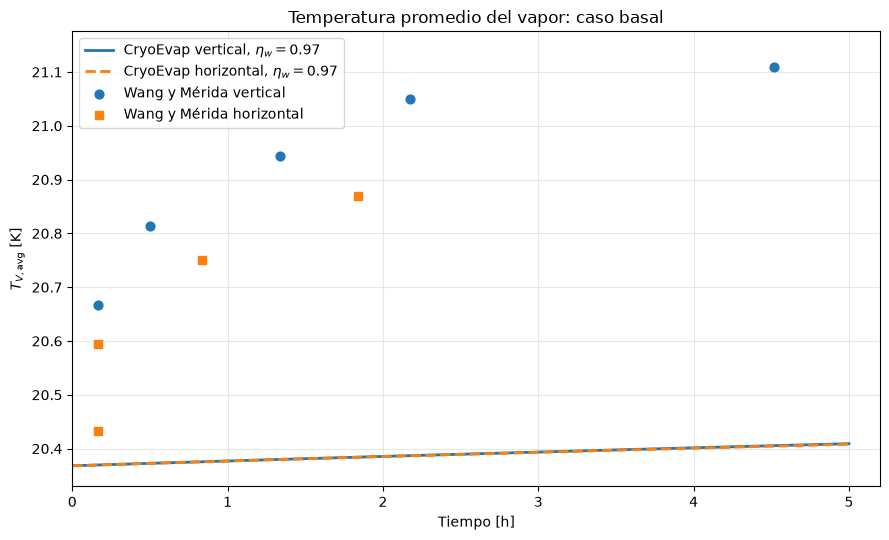

In [ ]:
# GRÁFICA 1: TEMPERATURA DE VAPOR BASAL

plt.figure(figsize=(9, 5.5))

plt.plot(time_vertical_short_h,Tv_avg_vertical_short,linewidth=2,label=r"CryoEvap vertical, $\eta_w=0.97$")

plt.plot(time_horizontal_short_h,Tv_avg_horizontal_short,linestyle="--",linewidth=2,label=r"CryoEvap horizontal, $\eta_w=0.97$")

plt.scatter(Tv_vert_wm["time"],Tv_vert_wm["value"],marker="o",s=40,label="Wang y Mérida vertical")

plt.scatter(Tv_horiz_wm["time"],Tv_horiz_wm["value"],marker="s",s=40,label="Wang y Mérida horizontal")

plt.xlim(0, 5.2)

plt.xlabel("Tiempo [h]")
plt.ylabel(r"$T_{V,\mathrm{avg}}$ [K]")

plt.title(
    r"Temperatura promedio del vapor: caso basal"
)

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

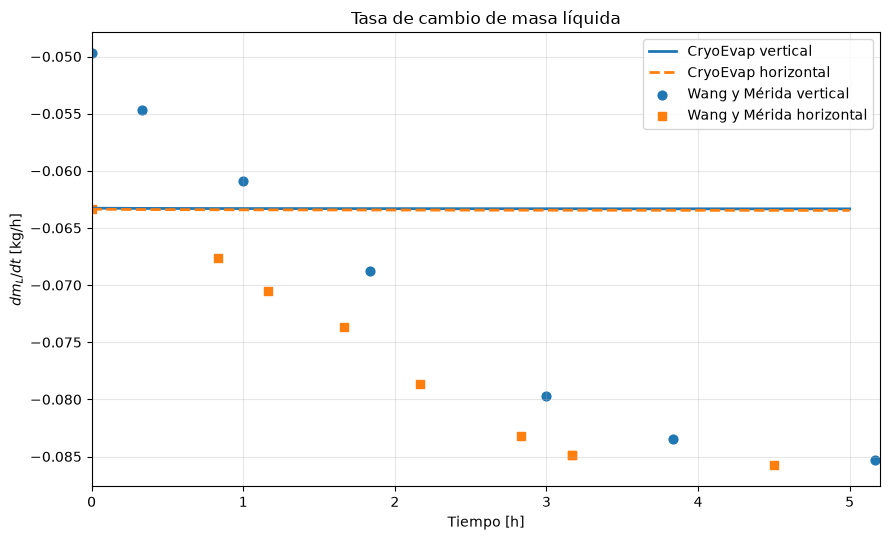

In [52]:
# GRÁFICA 2: CAMBIO DE MASA LÍQUIDA

plt.figure(figsize=(9, 5.5))

plt.plot(
    time_vertical_short_h,
    dMLdt_vertical_model,
    linewidth=2,
    label="CryoEvap vertical"
)

plt.plot(
    time_horizontal_short_h,
    dMLdt_horizontal_model,
    linestyle="--",
    linewidth=2,
    label="CryoEvap horizontal"
)

plt.scatter(
    dMLdt_vert_wm["time"],
    dMLdt_vert_wm["value"],
    marker="o",
    s=40,
    label="Wang y Mérida vertical"
)

plt.scatter(
    dMLdt_horiz_wm["time"],
    dMLdt_horiz_wm["value"],
    marker="s",
    s=40,
    label="Wang y Mérida horizontal"
)

plt.xlim(0, 5.2)

plt.xlabel("Tiempo [h]")
plt.ylabel(r"$dm_L/dt$ [kg/h]")

plt.title(
    r"Tasa de cambio de masa líquida"
)

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

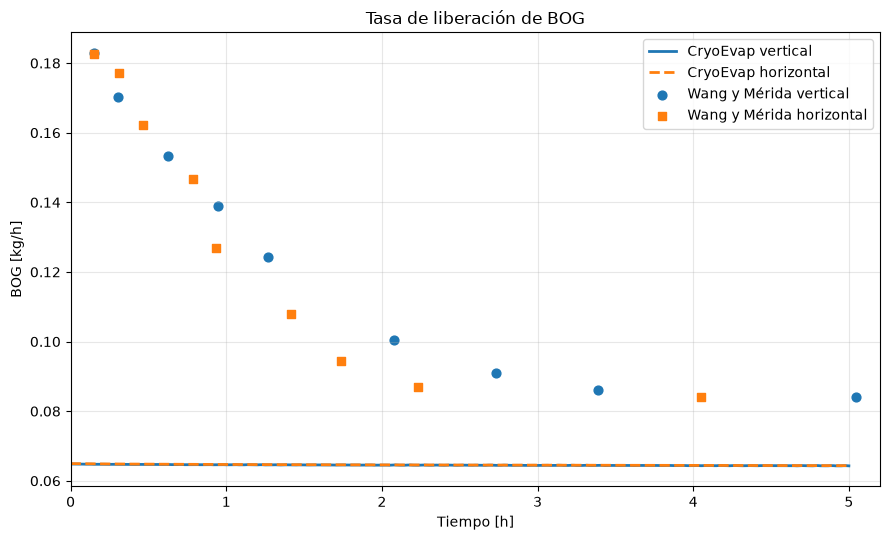

In [53]:
# GRÁFICA 3: BOG


plt.figure(figsize=(9, 5.5))

plt.plot(
    time_vertical_short_h,
    BOG_vertical_model,
    linewidth=2,
    label="CryoEvap vertical"
)

plt.plot(
    time_horizontal_short_h,
    BOG_horizontal_model,
    linestyle="--",
    linewidth=2,
    label="CryoEvap horizontal"
)

plt.scatter(
    BOG_vert_wm["time"],
    BOG_vert_wm["value"],
    marker="o",
    s=40,
    label="Wang y Mérida vertical"
)

plt.scatter(
    BOG_horiz_wm["time"],
    BOG_horiz_wm["value"],
    marker="s",
    s=40,
    label="Wang y Mérida horizontal"
)

plt.xlim(0, 5.2)

plt.xlabel("Tiempo [h]")
plt.ylabel("BOG [kg/h]")

plt.title(
    "Tasa de liberación de BOG"
)

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Simulacion con 160 h 

In [ ]:
# FUNCIÓN PARA SIMULACIONES DE LARGO PLAZO

def simulate_long_case(
    orientation,
    eta_value,
    simulation_hours=160.0,
    output_interval_seconds=300
):
    """
    Simula un tanque vertical u horizontal y devuelve sus
    resultados temporales en un DataFrame.

    Parameters
    ----------
    orientation : str
        "vertical" o "horizontal".
    eta_value : float
        Fracción eta_w.
    simulation_hours : float
        Duración total de la simulación en horas.
    output_interval_seconds : int
        Intervalo entre resultados almacenados.

    Returns
    -------
    tank : Tank
        Objeto simulado.
    results : pandas.DataFrame
        Resultados temporales.
    """

    hydrogen_case = Cryogen(name="hydrogen")
    hydrogen_case.set_coolprops(P)

    if orientation == "vertical":

        tank = Tank(
            d_i=d_i,
            d_o=d_o,
            V=V_tank,
            vapour_geometry="cylindrical",
            liquid_geometry="cylindrical",
            LF=LF_initial
        )

        Q_b_fixed = None

    elif orientation == "horizontal":

        tank = Tank(
            d_i=d_i,
            d_o=d_o,
            V=V_tank,
            vapour_geometry="horizontal",
            liquid_geometry="horizontal",
            LF=LF_initial,
            L=L_tank
        )

        Q_b_fixed = 0.0

    else:
        raise ValueError(
            "orientation debe ser 'vertical' o 'horizontal'."
        )

    tank.cryogen = hydrogen_case

    tank.set_HeatTransProps(
        U_L=U_equivalent,
        U_V=U_equivalent,
        T_air=T_air,
        Q_b_fixed=Q_b_fixed,
        Q_roof=0.0,
        eta_w=eta_value
    )

    # Malla espacial con dz aproximado de 1 cm
    n_z = max(3,1 + int(np.round(tank.l_V / dz_target)))

    tank.z_grid = np.linspace(0.0,1.0,n_z)

    tank.time_interval = output_interval_seconds

    simulation_seconds = int(simulation_hours * 3600)

    print(f"Ejecutando {orientation}, eta_w={eta_value:.2f}, t={simulation_hours:.1f} h...")

    tank.evaporate(simulation_seconds)

    if not tank.sol.success:
        raise RuntimeError(f"Falló la simulación {orientation}, eta_w={eta_value}.")

    time_h = tank.sol.t / 3600.0

    V_L = np.asarray(tank.data["V_L"])

    LF = np.asarray(tank.data["LF"])

    Tv_avg = np.asarray(tank.data["Tv_avg"])

    rho_V_avg = np.asarray(tank.data["rho_V_avg"])

    m_L = tank.cryogen.rho_L * V_L

    m_V = (rho_V_avg* (V_tank - V_L))

    # Tasas mediante balance de masa
    dMLdt = np.gradient(m_L,time_h)

    dMVdt = np.gradient(m_V,time_h)

    evaporation = -dMLdt

    BOG = -(dMLdt+ dMVdt)

    results = pd.DataFrame({
        "time_h": time_h,
        "Tv_avg_K": Tv_avg,
        "LF": LF,
        "LF_pct": 100.0 * LF,
        "mL_kg": m_L,
        "mV_kg": m_V,
        "dMLdt_kg_h": dMLdt,
        "evap_kg_h": evaporation,
        "BOG_kg_h": BOG
    })

    # Comprobaciones mínimas (IA)
    assert np.all(
        np.isfinite(
            results.select_dtypes(
                include=[np.number]
            ).to_numpy()
        )
    )

    assert np.all(
        results["LF"] > 0.0
    )

    assert np.all(
        results["mL_kg"] > 0.0
    )

    print(f"Terminada: {orientation}, eta_w={eta_value:.2f}, nfev={tank.sol.nfev}"    )

    return tank, results

In [60]:
# SIMULACIÓN BASAL DE 160 HORAS

vertical_160_baseline, vertical_160_baseline_df = (
    simulate_long_case(
        orientation="vertical",
        eta_value=0.97,
        simulation_hours=160.0,
        output_interval_seconds=300
    )
)

horizontal_160_baseline, horizontal_160_baseline_df = (
    simulate_long_case(
        orientation="horizontal",
        eta_value=0.97,
        simulation_hours=160.0,
        output_interval_seconds=300
    )
)

Ejecutando vertical, eta_w=0.97, t=160.0 h...
Terminada: vertical, eta_w=0.97, nfev=53888
Ejecutando horizontal, eta_w=0.97, t=160.0 h...
Terminada: horizontal, eta_w=0.97, nfev=57842


In [61]:
# RESUMEN BASAL A 160 HORAS

summary_160_baseline = pd.DataFrame({
    "geometry": [
        "vertical",
        "horizontal"
    ],

    "eta_w": [
        0.97,
        0.97
    ],

    "Tv_160h_K": [
        vertical_160_baseline_df["Tv_avg_K"].iloc[-1],
        horizontal_160_baseline_df["Tv_avg_K"].iloc[-1]
    ],

    "LF_160h_pct": [
        vertical_160_baseline_df["LF_pct"].iloc[-1],
        horizontal_160_baseline_df["LF_pct"].iloc[-1]
    ],

    "mL_160h_kg": [
        vertical_160_baseline_df["mL_kg"].iloc[-1],
        horizontal_160_baseline_df["mL_kg"].iloc[-1]
    ],

    "dMLdt_160h_kg_h": [
        vertical_160_baseline_df["dMLdt_kg_h"].iloc[-1],
        horizontal_160_baseline_df["dMLdt_kg_h"].iloc[-1]
    ],

    "BOG_160h_kg_h": [
        vertical_160_baseline_df["BOG_kg_h"].iloc[-1],
        horizontal_160_baseline_df["BOG_kg_h"].iloc[-1]
    ]
})

summary_160_baseline

,geometry,eta_w,Tv_160h_K,LF_160h_pct,mL_160h_kg,dMLdt_160h_kg_h,BOG_160h_kg_h
0,vertical,0.97,20.685204,27.075580,93.804179,-0.063300,0.062161
1,horizontal,0.97,20.669589,27.064991,93.767493,-0.063559,0.062432


In [ ]:
# REFERENCIAS DIGITALIZADAS HASTA 160 HORAS

Tv_vert_wm_160 = Tv_vert_wm[
    Tv_vert_wm["time"] <= 160.0
]

Tv_horiz_wm_160 = Tv_horiz_wm[
    Tv_horiz_wm["time"] <= 160.0
]

LF_wm_160 = LF_wm[
    LF_wm["time"] <= 160.0
]

mL_wm_160 = mL_wm[
    mL_wm["time"] <= 160.0
]

dMLdt_vert_wm_160 = dMLdt_vert_wm[
    dMLdt_vert_wm["time"] <= 160.0
]

dMLdt_horiz_wm_160 = dMLdt_horiz_wm[
    dMLdt_horiz_wm["time"] <= 160.0
]

BOG_vert_wm_160 = BOG_vert_wm[
    BOG_vert_wm["time"] <= 160.0
]

BOG_horiz_wm_160 = BOG_horiz_wm[
    BOG_horiz_wm["time"] <= 160.0
]

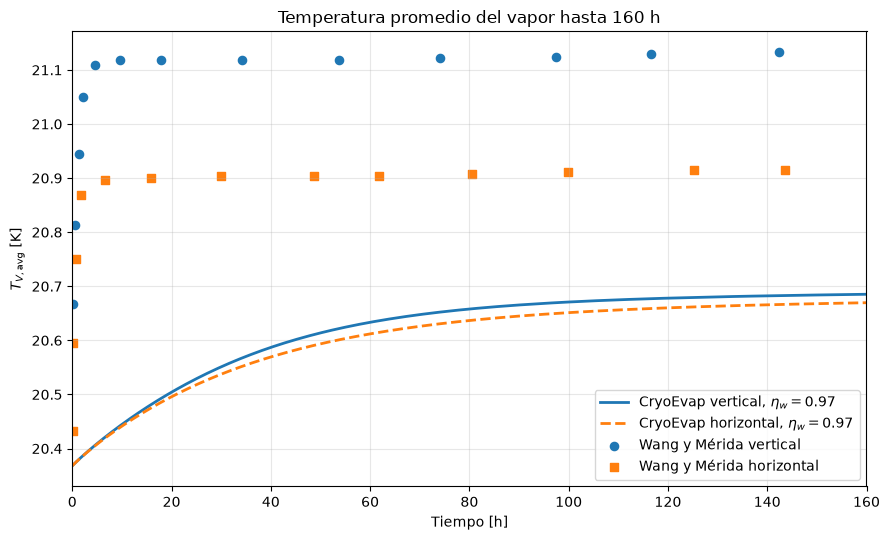

In [63]:
# FIGURA 12(a): TEMPERATURA HASTA 160 h

plt.figure(figsize=(9, 5.5))

plt.plot(
    vertical_160_baseline_df["time_h"],
    vertical_160_baseline_df["Tv_avg_K"],
    linewidth=2,
    label=r"CryoEvap vertical, $\eta_w=0.97$"
)

plt.plot(
    horizontal_160_baseline_df["time_h"],
    horizontal_160_baseline_df["Tv_avg_K"],
    linestyle="--",
    linewidth=2,
    label=r"CryoEvap horizontal, $\eta_w=0.97$"
)

plt.scatter(
    Tv_vert_wm_160["time"],
    Tv_vert_wm_160["value"],
    marker="o",
    s=35,
    label="Wang y Mérida vertical"
)

plt.scatter(
    Tv_horiz_wm_160["time"],
    Tv_horiz_wm_160["value"],
    marker="s",
    s=35,
    label="Wang y Mérida horizontal"
)

plt.xlim(0, 160)

plt.xlabel("Tiempo [h]")
plt.ylabel(r"$T_{V,\mathrm{avg}}$ [K]")
plt.title("Temperatura promedio del vapor hasta 160 h")

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

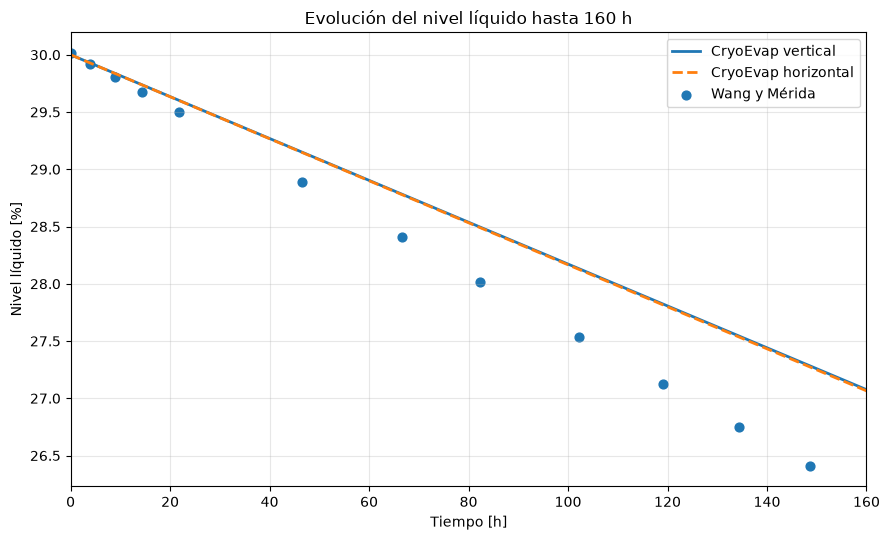

In [64]:
# FIGURA 12(b): NIVEL LÍQUIDO HASTA 160 h


plt.figure(figsize=(9, 5.5))

plt.plot(
    vertical_160_baseline_df["time_h"],
    vertical_160_baseline_df["LF_pct"],
    linewidth=2,
    label="CryoEvap vertical"
)

plt.plot(
    horizontal_160_baseline_df["time_h"],
    horizontal_160_baseline_df["LF_pct"],
    linestyle="--",
    linewidth=2,
    label="CryoEvap horizontal"
)

plt.scatter(
    LF_wm_160["time"],
    LF_wm_160["value"],
    marker="o",
    s=40,
    label="Wang y Mérida"
)

plt.xlim(0, 160)

plt.xlabel("Tiempo [h]")
plt.ylabel("Nivel líquido [%]")
plt.title("Evolución del nivel líquido hasta 160 h")

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

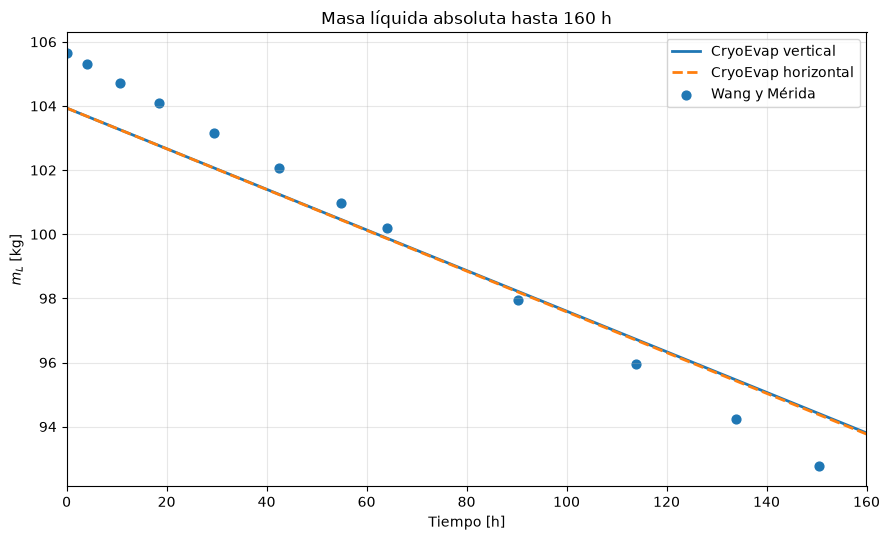

In [65]:
# FIGURA 12(c): MASA LÍQUIDA ABSOLUTA

plt.figure(figsize=(9, 5.5))

plt.plot(
    vertical_160_baseline_df["time_h"],
    vertical_160_baseline_df["mL_kg"],
    linewidth=2,
    label="CryoEvap vertical"
)

plt.plot(
    horizontal_160_baseline_df["time_h"],
    horizontal_160_baseline_df["mL_kg"],
    linestyle="--",
    linewidth=2,
    label="CryoEvap horizontal"
)

plt.scatter(
    mL_wm_160["time"],
    mL_wm_160["value"],
    marker="o",
    s=40,
    label="Wang y Mérida"
)

plt.xlim(0, 160)

plt.xlabel("Tiempo [h]")
plt.ylabel(r"$m_L$ [kg]")
plt.title("Masa líquida absoluta hasta 160 h")

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

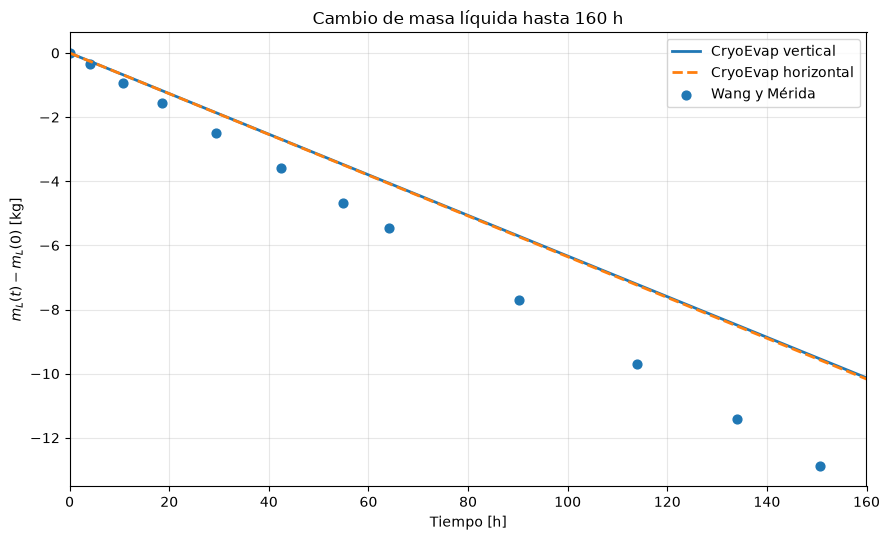

In [66]:
# CAMBIO DE MASA LÍQUIDA RESPECTO DEL ESTADO INICIAL aca cambia la densidad por la del paper

delta_mL_vertical = (
    vertical_160_baseline_df["mL_kg"]
    - vertical_160_baseline_df["mL_kg"].iloc[0]
)

delta_mL_horizontal = (
    horizontal_160_baseline_df["mL_kg"]
    - horizontal_160_baseline_df["mL_kg"].iloc[0]
)

delta_mL_wm = (
    mL_wm_160["value"]
    - mL_wm_160["value"].iloc[0]
)

plt.figure(figsize=(9, 5.5))

plt.plot(
    vertical_160_baseline_df["time_h"],
    delta_mL_vertical,
    linewidth=2,
    label="CryoEvap vertical"
)

plt.plot(
    horizontal_160_baseline_df["time_h"],
    delta_mL_horizontal,
    linestyle="--",
    linewidth=2,
    label="CryoEvap horizontal"
)

plt.scatter(
    mL_wm_160["time"],
    delta_mL_wm,
    marker="o",
    s=40,
    label="Wang y Mérida"
)

plt.xlim(0, 160)

plt.xlabel("Tiempo [h]")
plt.ylabel(r"$m_L(t)-m_L(0)$ [kg]")
plt.title("Cambio de masa líquida hasta 160 h")

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

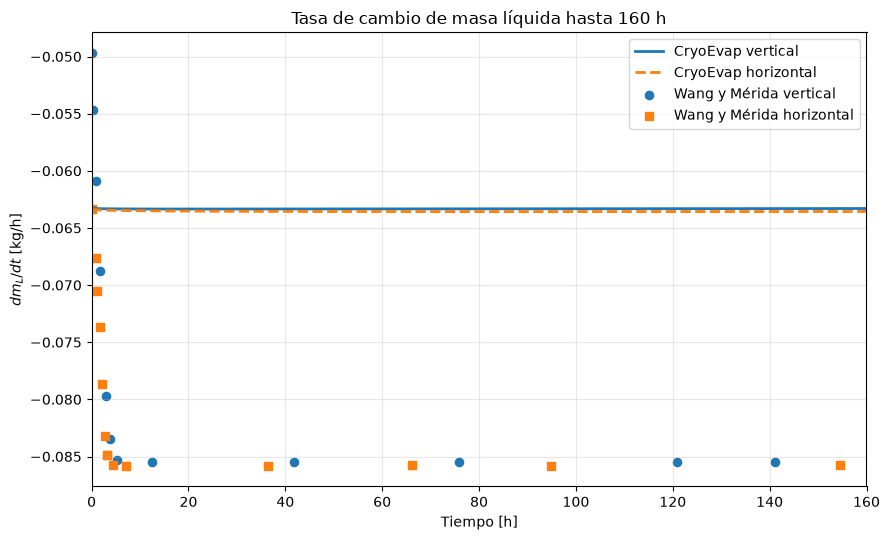

In [67]:
# FIGURA 12(d): CAMBIO DE MASA LÍQUIDA

plt.figure(figsize=(9, 5.5))

plt.plot(
    vertical_160_baseline_df["time_h"],
    vertical_160_baseline_df["dMLdt_kg_h"],
    linewidth=2,
    label="CryoEvap vertical"
)

plt.plot(
    horizontal_160_baseline_df["time_h"],
    horizontal_160_baseline_df["dMLdt_kg_h"],
    linestyle="--",
    linewidth=2,
    label="CryoEvap horizontal"
)

plt.scatter(
    dMLdt_vert_wm_160["time"],
    dMLdt_vert_wm_160["value"],
    marker="o",
    s=35,
    label="Wang y Mérida vertical"
)

plt.scatter(
    dMLdt_horiz_wm_160["time"],
    dMLdt_horiz_wm_160["value"],
    marker="s",
    s=35,
    label="Wang y Mérida horizontal"
)

plt.xlim(0, 160)

plt.xlabel("Tiempo [h]")
plt.ylabel(r"$dm_L/dt$ [kg/h]")
plt.title("Tasa de cambio de masa líquida hasta 160 h")

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

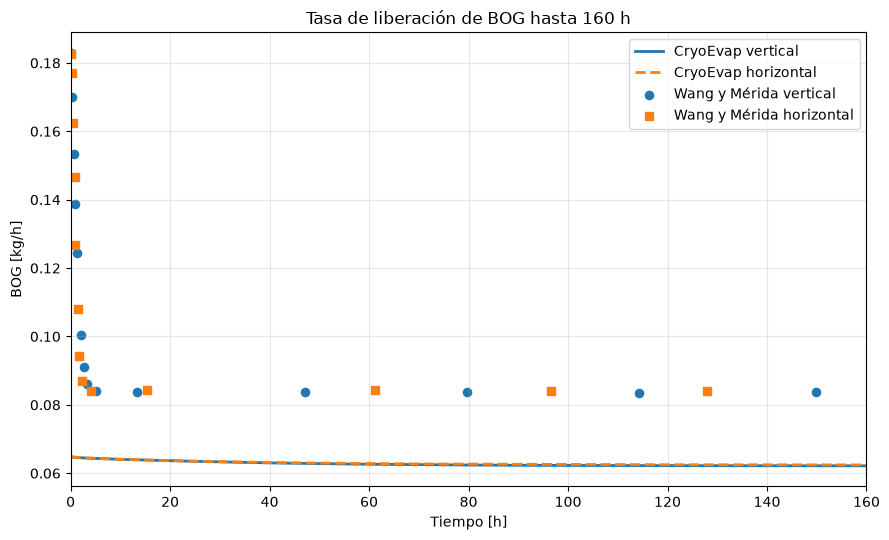

In [68]:
# FIGURA 12(e): BOG HASTA 160 h

plt.figure(figsize=(9, 5.5))

plt.plot(
    vertical_160_baseline_df["time_h"],
    vertical_160_baseline_df["BOG_kg_h"],
    linewidth=2,
    label="CryoEvap vertical"
)

plt.plot(
    horizontal_160_baseline_df["time_h"],
    horizontal_160_baseline_df["BOG_kg_h"],
    linestyle="--",
    linewidth=2,
    label="CryoEvap horizontal"
)

plt.scatter(
    BOG_vert_wm_160["time"],
    BOG_vert_wm_160["value"],
    marker="o",
    s=35,
    label="Wang y Mérida vertical"
)

plt.scatter(
    BOG_horiz_wm_160["time"],
    BOG_horiz_wm_160["value"],
    marker="s",
    s=35,
    label="Wang y Mérida horizontal"
)

plt.xlim(0, 160)

plt.xlabel("Tiempo [h]")
plt.ylabel("BOG [kg/h]")
plt.title("Tasa de liberación de BOG hasta 160 h")

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [69]:
# CASO eta_w = 0.50

vertical_160_eta050, vertical_160_eta050_df = (
    simulate_long_case(
        orientation="vertical",
        eta_value=0.50,
        simulation_hours=160.0,
        output_interval_seconds=300
    )
)

horizontal_160_eta050, horizontal_160_eta050_df = (
    simulate_long_case(
        orientation="horizontal",
        eta_value=0.50,
        simulation_hours=160.0,
        output_interval_seconds=300
    )
)

Ejecutando vertical, eta_w=0.50, t=160.0 h...
Terminada: vertical, eta_w=0.50, nfev=99890
Ejecutando horizontal, eta_w=0.50, t=160.0 h...
Terminada: horizontal, eta_w=0.50, nfev=95114


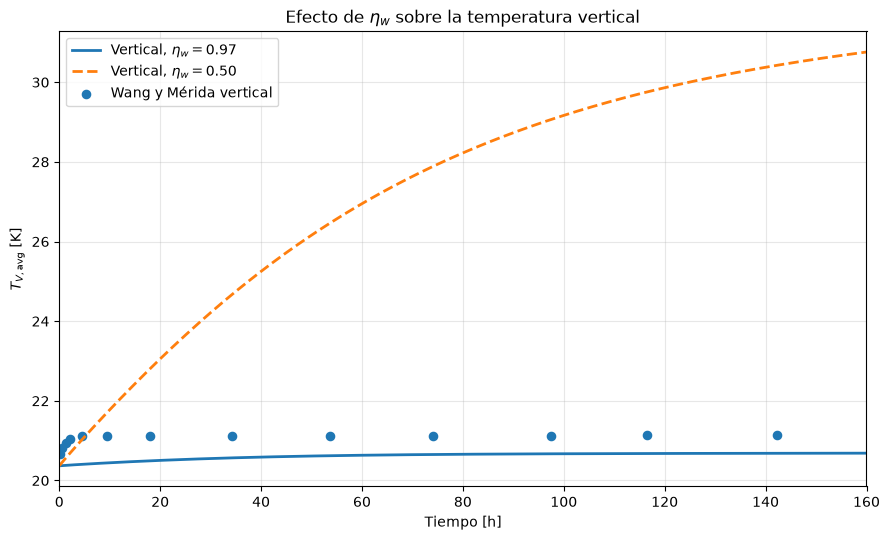

In [70]:
plt.figure(figsize=(9, 5.5))

plt.plot(
    vertical_160_baseline_df["time_h"],
    vertical_160_baseline_df["Tv_avg_K"],
    linewidth=2,
    label=r"Vertical, $\eta_w=0.97$"
)

plt.plot(
    vertical_160_eta050_df["time_h"],
    vertical_160_eta050_df["Tv_avg_K"],
    linestyle="--",
    linewidth=2,
    label=r"Vertical, $\eta_w=0.50$"
)

plt.scatter(
    Tv_vert_wm_160["time"],
    Tv_vert_wm_160["value"],
    marker="o",
    s=35,
    label="Wang y Mérida vertical"
)

plt.xlim(0, 160)

plt.xlabel("Tiempo [h]")
plt.ylabel(r"$T_{V,\mathrm{avg}}$ [K]")
plt.title(r"Efecto de $\eta_w$ sobre la temperatura vertical")

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()